In [1]:
import pysmile
import pysmile_license
from pathlib import Path
from pysmile.learning import DataSet, EM
import itertools
from expdef import Experiment, Analytic, Result
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
fileName = "DBNfromAG_learned.xdsl"
dataFileName = "dbnLogs.csv"
targetNodes = ["tomcatWebServer_bruteForce", "DMZ_scanIP", "historian_scanVuln", "IED1_DERfailure"]
fixedNodes = ["historianServer_remoteShellAND", "MMSclient1_AND52", "MMSserver1_NodeAND23", "historianServer_NodeOR1"]
numSlices = 100

algoTypeExact = True

ext_ev_every_n_slices = [1,2,5,10]
numFolds = 5

In [3]:
net = pysmile.Network()
net.read_file(fileName)
net.set_slice_count(numSlices)
if not algoTypeExact:
    # Set default inference algorithm and parameters
    net.set_bayesian_algorithm(pysmile.BayesianAlgorithmType.EPIS_SAMPLING)
    #pysmile.EPISParams.num_state_big
    # Print default EPIS algorithm parameters
    episParams = net.get_epis_params()
    episParams.propagation_length = 20  # Example modification
    net.set_epis_params(episParams)
    print("Propagation length: ", episParams.propagation_length)
    print("Num state small:", episParams.num_state_small)
    print("Num state medium:", episParams.num_state_medium)
    print("Num state big:", episParams.num_state_big)
else:
    net.set_bayesian_algorithm(pysmile.BayesianAlgorithmType.LAURITZEN)

In [4]:
def plotDefinitions(net: pysmile.Network):
    nodeHandles = net.get_all_nodes()
    nodeIds = net.get_all_node_ids()
    for nodeHandle, nodeId in zip(nodeHandles, nodeIds):
        nodeDef = net.get_node_definition(nodeHandle)
        nodeOutcomes = net.get_outcome_ids(nodeHandle)
        print(f"Node ID: {nodeId}, Definition: {nodeDef}, Outcomes: {nodeOutcomes}")

In [5]:
from validator import Validator

validator: Validator = Validator(net, dataFileName, fixedNodes)
for targetNode in targetNodes:
    validator.addClassNode(targetNode)

full_results_df = pd.DataFrame()
for ev_every_n_slices in ext_ev_every_n_slices:
    print(f"Evaluating with evEveryNSlices = {ev_every_n_slices}")
    validator.set_ev_every_n_slices(ev_every_n_slices)
    results_df = validator.kFold(nFolds=numFolds)
    results_df.to_csv(f"results/{numFolds}_folds-evEveryNSlices_{ev_every_n_slices}.csv", index=False)
    full_results_df = pd.concat([full_results_df, results_df], ignore_index=True)
full_results_df.to_csv(f"results/{numFolds}_folds-full_results.csv", index=False)

Evaluating with evEveryNSlices = 1
Fold 1/5 -- Accuracy: 0.9818, Precision: 0.9913, Recall: 0.9833, F1-score: 0.9873, MCC: 0.9551
Fold 2/5 -- Accuracy: 0.9834, Precision: 0.9898, Recall: 0.9868, F1-score: 0.9883, MCC: 0.9596
Fold 3/5 -- Accuracy: 0.9802, Precision: 0.9865, Recall: 0.9855, F1-score: 0.9860, MCC: 0.9525
Fold 4/5 -- Accuracy: 0.9825, Precision: 0.9912, Recall: 0.9837, F1-score: 0.9874, MCC: 0.9587
Fold 5/5 -- Accuracy: 0.9819, Precision: 0.9861, Recall: 0.9877, F1-score: 0.9869, MCC: 0.9573
Average Accuracy: 0.9819 ± 0.0010
Average Precision: 0.9890 ± 0.0022
Average Recall: 0.9854 ± 0.0017
Average F1-score: 0.9872 ± 0.0007
Average MCC: 0.9567 ± 0.0026
Evaluating with evEveryNSlices = 2
Fold 1/5 -- Accuracy: 0.9830, Precision: 0.9932, Recall: 0.9832, F1-score: 0.9881, MCC: 0.9583
Fold 2/5 -- Accuracy: 0.9836, Precision: 0.9896, Recall: 0.9873, F1-score: 0.9885, MCC: 0.9602
Fold 3/5 -- Accuracy: 0.9804, Precision: 0.9867, Recall: 0.9855, F1-score: 0.9861, MCC: 0.9529
Fold 4

In [5]:
# Load full results from CSV if needed
full_results_df = pd.read_csv(f"results/{numFolds}_folds-full_results.csv")

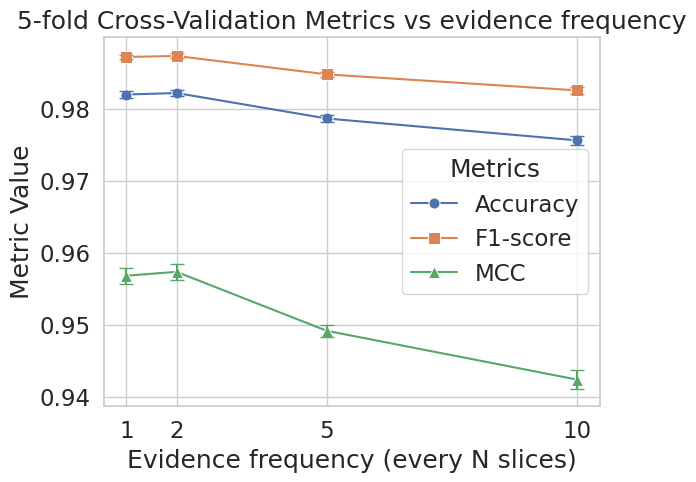

In [21]:
# Plot the full results using a line plot (one line per metric with error bars)
metrics = ['Accuracy', 'F1-score', 'MCC']
metricsStd = [f'Std-Accuracy', f'Std-F1-score', f'Std-MCC']
markers = ['o', 's', '^']  # circle, square, triangle
sns.set(font_scale=1.5)
sns.set_style("whitegrid")
for metric, metricStd, marker in zip(metrics, metricsStd, markers):
    ax = plt.gca()
    # Set a different marker for each metric
    sns.lineplot(data=full_results_df, x='evEveryN', y=metric, marker=marker, label=metric, markersize=8)
    color = ax.lines[-1].get_color()
    # Add error bars
    plt.errorbar(full_results_df['evEveryN'], full_results_df[metric], yerr=full_results_df[metricStd], fmt='none', capsize=5, ecolor=color, color=color)
plt.title(f'{numFolds}-fold Cross-Validation Metrics vs evidence frequency'.format(numFolds))
plt.xlabel('Evidence frequency (every N slices)')
plt.ylabel('Metric Value')
plt.legend(title='Metrics')
plt.grid(True)
plt.xticks(ext_ev_every_n_slices)
plt.savefig('plots/validation_metrics_vs_evEveryNSlices.png', bbox_inches='tight')